# Sleep Quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Loading the Dataset

In [2]:
df = pd.read_csv("sleep_health_dataset.csv")

In [3]:
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [4]:
df.shape

(100000, 32)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  alcohol_uni

## 2. Data Cleaning

In [6]:
df.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [7]:
pd.set_option('display.max_columns', None)
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [8]:
print(df['sleep_quality_score'].unique())

[ 6.6  6.9  1.   6.4  3.2  5.7  5.1  6.5  5.4  4.9  2.8  4.6  4.4  3.7
  4.8  5.9  6.7  4.7  5.5  7.4  7.1  4.5  5.3  7.3  5.6  2.6  2.3  6.3
  6.1  4.1  5.2  6.8  3.1  7.2  3.8  4.3  1.5  7.7  3.4  3.9  5.   6.2
  2.1  3.   2.7  4.2  3.6  6.   4.   3.3  7.5  3.5  2.9  5.8  7.9  2.
  2.2  1.7  7.   8.3  1.1  1.8  1.4  2.5  7.6  7.8  1.2  8.2  8.9  1.6
  1.9  8.   1.3  2.4  8.1  8.4  8.7  8.6  9.2  9.1  8.8  8.5  9.4  9.3
  9.   9.6  9.7 10.   9.5]


In [9]:
df.drop(columns=['person_id'], inplace=True)

In [10]:
df.isnull().sum()

age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_disorder_risk            0
felt_reste

**Comment:** There are still no missing values after removing `person_id`.

## 3. Feature Engineering & encoding

In [11]:
#Convert screen time from minutes to hours
df["screen_time_before_bed_hrs"] = (df["screen_time_before_bed_mins"] / 60)

In [12]:
#Combined effect of stress and work hours
df["work_stress_load"] = (df["work_hours_that_day"] * df["stress_score"])

In [13]:
#Total percentage of restorative sleep
df["restorative_sleep_percentage"] = (df["rem_percentage"] +df["deep_sleep_percentage"])

The value is 1 if the person took a nap and 0 if not.

In [14]:
#Whether the person took a nap
df["took_nap"] = (df["nap_duration_mins"] > 0).astype(int)

In [15]:
# Remove the original screen-time column because we converted it to hours
df = df.drop(columns=["screen_time_before_bed_mins"])
display(df[["screen_time_before_bed_hrs", "work_stress_load", "restorative_sleep_percentage", "took_nap"]].head())

,screen_time_before_bed_hrs,work_stress_load,restorative_sleep_percentage,took_nap
0,0.533333,47.08,41.8,0
1,0.550000,12.00,41.8,1
2,1.483333,28.08,36.4,1
3,0.866667,32.83,35.4,1
4,1.200000,76.96,41.6,0


In [16]:
# Shift work labels
df["shift_work_status"] = df["shift_work"].map({
    0: "No Shift Work",
    1: "Shift Work"})

Divide stress into Low, Moderate, and High.
Also divide sleep duration into Short, Medium, and Long.

In [17]:
# Stress categories
df["stress_level"] = pd.cut(
    df["stress_score"],
    bins=[-float("inf"), 3, 6, float("inf")],
    labels=["Low", "Moderate", "High"]
)

# Sleep-duration categories
df["sleep_duration_level"] = pd.cut(
    df["sleep_duration_hrs"],
    bins=[-float("inf"), 6, 8, float("inf")],
    labels=["Short", "Medium", "Long"]
)

## 4. Data Visualization

Stress and Sleep Quality:

Does higher stress relate to lower sleep quality?

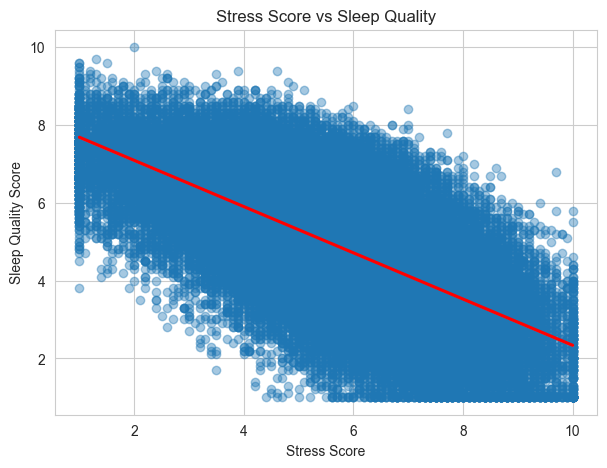

In [18]:
plt.figure(figsize=(7, 5))

sns.regplot(data=df,x="stress_score",y="sleep_quality_score",scatter_kws={"alpha": 0.4},line_kws={"color": "red"})

plt.title("Stress Score vs Sleep Quality")
plt.xlabel("Stress Score")
plt.ylabel("Sleep Quality Score")
plt.show()

**Insight:** I can see a clear negative relationship. When stress increases, sleep quality usually decreases.

Sleep Duration and Sleep Quality:

Does longer sleep relate to better sleep quality?

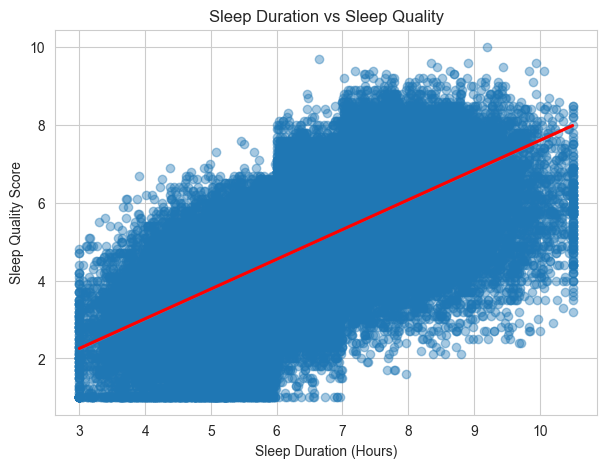

In [19]:
plt.figure(figsize=(7, 5))

sns.regplot(data=df,x="sleep_duration_hrs",y="sleep_quality_score",scatter_kws={"alpha": 0.4},line_kws={"color": "red"})

plt.title("Sleep Duration vs Sleep Quality")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Sleep Quality Score")
plt.show()

**Insight:** I can see a positive relationship. People who sleep for more hours usually have better sleep quality.

Exercise and Sleep Quality:

Is the average sleep quality different for people who exercise?

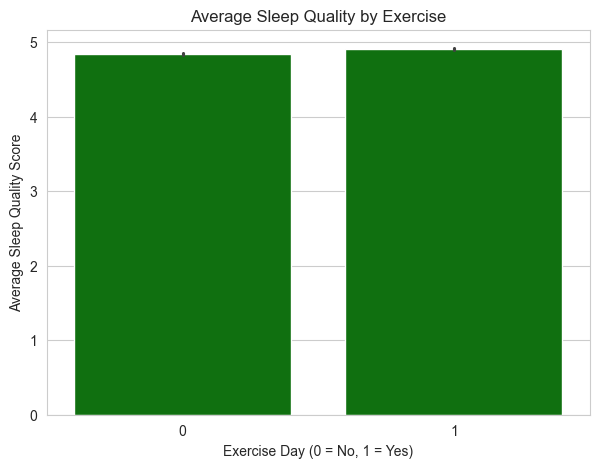

In [20]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="exercise_day",
    y="sleep_quality_score",
    color="green")

plt.title("Average Sleep Quality by Exercise")
plt.xlabel("Exercise Day (0 = No, 1 = Yes)")
plt.ylabel("Average Sleep Quality Score")
plt.show()

**Insight:** The exercise group has slightly better sleep quality, but the difference is small.

Mental Health and Sleep Quality:

Does sleep quality change between mental health groups?

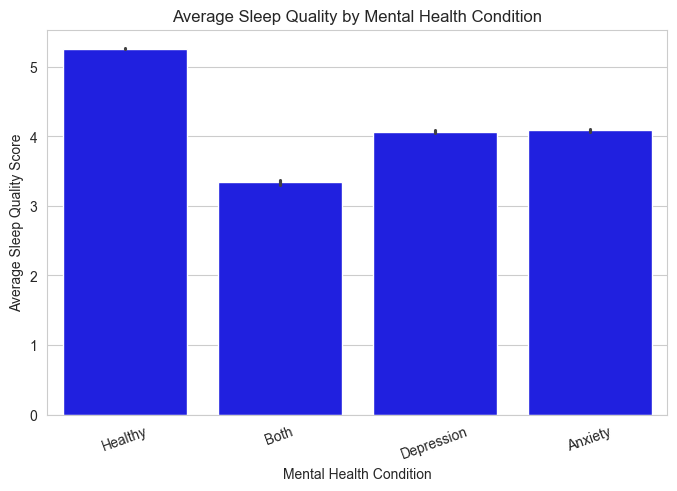

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="mental_health_condition",
    y="sleep_quality_score",
    color="blue"
)

plt.title("Average Sleep Quality by Mental Health Condition")
plt.xlabel("Mental Health Condition")
plt.ylabel("Average Sleep Quality Score")
plt.xticks(rotation=20)
plt.show()

**Insight:** The Healthy group has the highest average sleep quality. The Both group has the lowest average.

Shift Work and Sleep Quality:

Is shift work related to lower sleep quality?

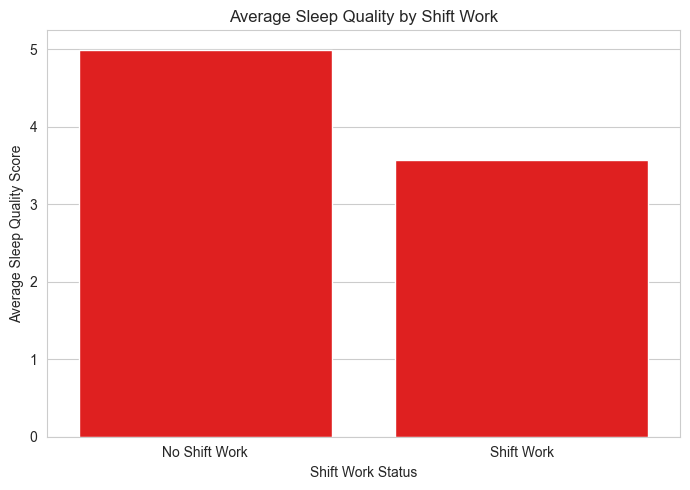

In [22]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="shift_work_status",
    y="sleep_quality_score",
    color="red",
    errorbar=None
)

plt.title("Average Sleep Quality by Shift Work")
plt.xlabel("Shift Work Status")
plt.ylabel("Average Sleep Quality Score")

plt.tight_layout()
plt.show()

**Insight:** People without shift work have an average close to 5.0, while shift workers are close to 3.6. Shift workers have lower sleep quality in this dataset.

Stress Level and Sleep Quality:

How does sleep quality change between stress levels?

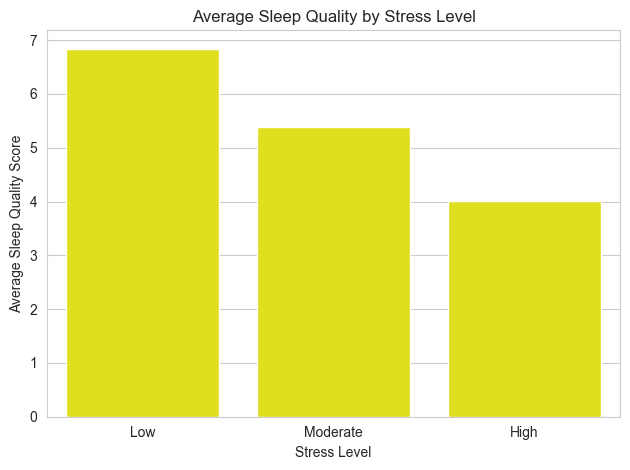

In [23]:
sns.barplot(
    data=df,
    x="stress_level",
    y="sleep_quality_score",
    color="yellow",
    errorbar=None
)

plt.title("Average Sleep Quality by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Average Sleep Quality Score")

plt.tight_layout()
plt.show()


**Insight:** Sleep quality becomes lower when the stress level increases. The Low group is the highest and the High group is the lowest.

Sleep Duration Groups:

Which sleep-duration group has the best average sleep quality?

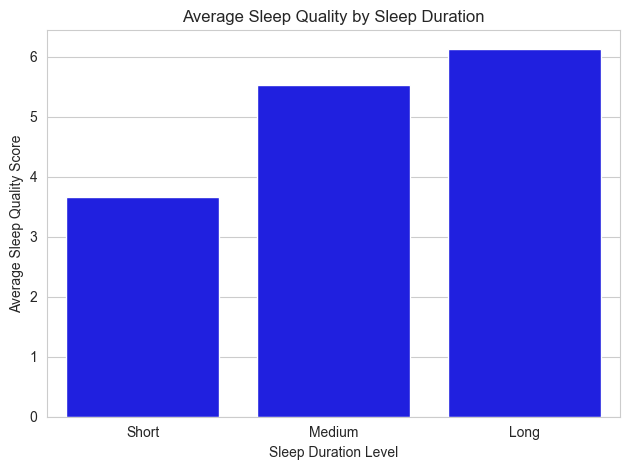

In [24]:
sns.barplot(
    data=df,
    x="sleep_duration_level",
    y="sleep_quality_score",
    color="blue",
    errorbar=None
)

plt.title("Average Sleep Quality by Sleep Duration")
plt.xlabel("Sleep Duration Level")
plt.ylabel("Average Sleep Quality Score")

plt.tight_layout()
plt.show()

**Insight:** The Long sleep group has the highest average sleep quality. The Short group has the lowest average.

### Correlation Heatmap:

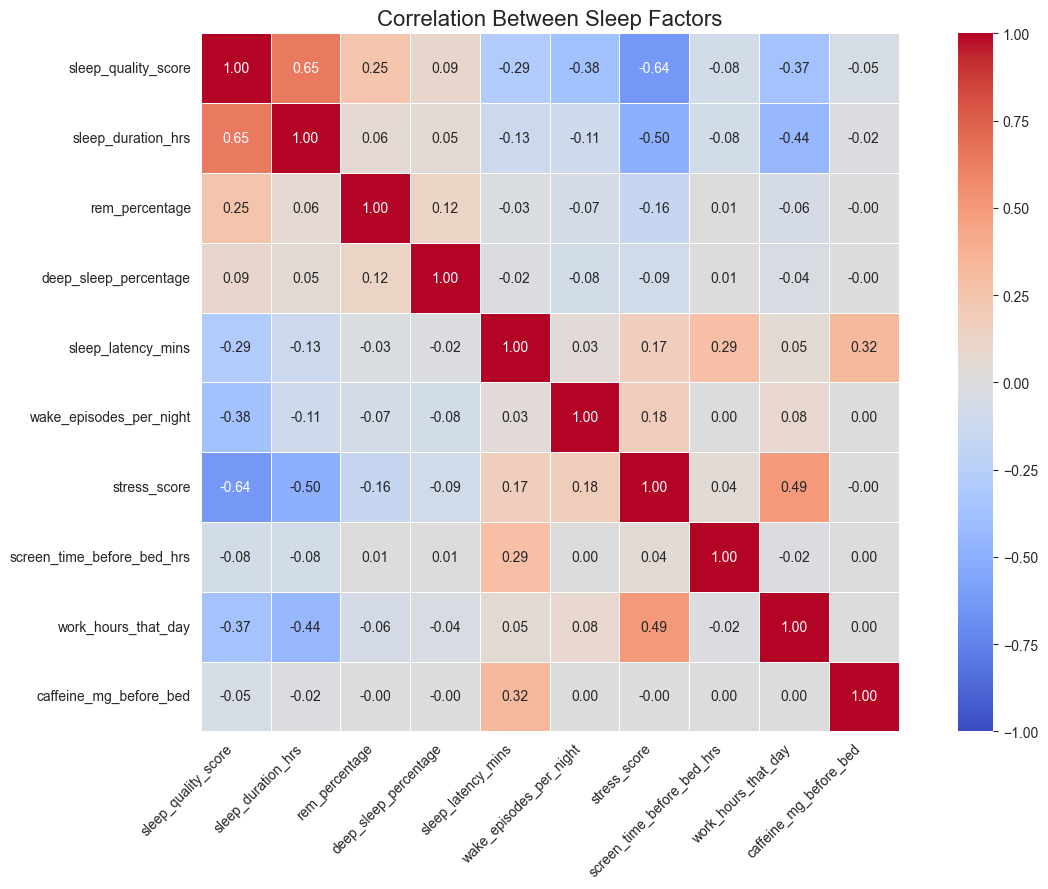

In [25]:
selected_columns = [
    "sleep_quality_score",
    "sleep_duration_hrs",
    "rem_percentage",
    "deep_sleep_percentage",
    "sleep_latency_mins",
    "wake_episodes_per_night",
    "stress_score",
    "screen_time_before_bed_hrs",
    "work_hours_that_day",
    "caffeine_mg_before_bed"
]


selected_columns = [
    column for column in selected_columns
    if column in df.columns
]

correlation_matrix = df[selected_columns].corr()

plt.figure(figsize=(13, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Between Sleep Factors", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Model Training & Evaluation

## Target 1 - Predicting sleep_quality_score

In [26]:
y = df["sleep_quality_score"]

# Remove the target and unnecessary columns from the features
columns_to_remove = [ "sleep_quality_score","felt_rested","sleep_disorder_risk","cognitive_performance_score","shift_work_status","stress_level", "sleep_duration_level"]

X = df.drop(columns=columns_to_remove)

I split the data into training and testing sets. I use 80% for training and 20% for testing.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print( X_train.shape)
print( X_test.shape)

(80000, 30)
(20000, 30)


***Feature Engineering*** separate numerical and categorical columns.

Numerical missing values will be filled with the median, while categorical features will be converted into numbers using One-Hot Encoding.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


numerical_columns = X_train.select_dtypes(include="number").columns
categorical_columns = X_train.select_dtypes(exclude="number").columns

print("Numerical columns:", len(numerical_columns))
print("Categorical columns:", len(categorical_columns))


# Fill missing numerical values with the median
numerical_preprocessing = SimpleImputer(strategy="median")


# Prepare categorical columns
categorical_preprocessing = Pipeline([("fill_missing",SimpleImputer(strategy="most_frequent")),# Fill missing values with the most common value
    ("one_hot_encoding",OneHotEncoder(handle_unknown="ignore"))])# Convert text values into numbers


# Apply the correct preprocessing to each column type
preprocessor = ColumnTransformer([("numerical",numerical_preprocessing,numerical_columns),("categorical",categorical_preprocessing,categorical_columns)])

Numerical columns: 23
Categorical columns: 7


### Modeling

**Random Forest Regressor** to predict the sleep quality score.

Combine the **preprocessing** and the model in **one pipeline**.

In [29]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([("preprocessor",preprocessor),("random_forest",RandomForestRegressor(n_estimators=100,max_depth=15,random_state=42,n_jobs=-1))])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

### Evaluation

In [30]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

MAE: 0.503
RMSE: 0.629
R²: 0.828


**Insight:** The model explains 82.8% of the variation in sleep quality, with an average prediction error of about 0.50 points.

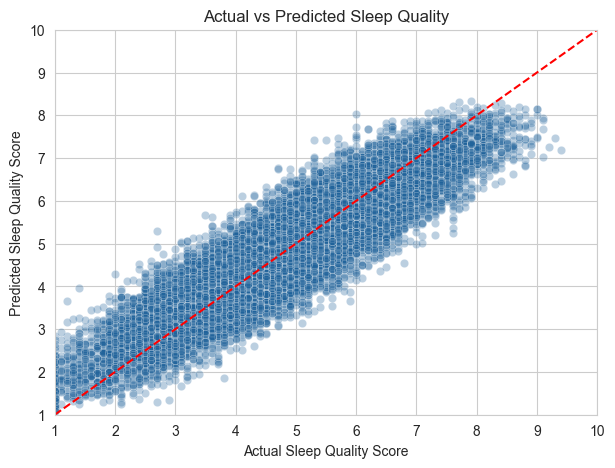

In [31]:
plt.figure(figsize=(7, 5))

sns.scatterplot(x=y_test,y=y_pred,alpha=0.3,color="#20639B")

plt.plot([1, 10],[1, 10],color="red",linestyle="--")

plt.title("Actual vs Predicted Sleep Quality")
plt.xlabel("Actual Sleep Quality Score")
plt.ylabel("Predicted Sleep Quality Score")
plt.xlim(1, 10)
plt.ylim(1, 10)
plt.show()

**Insight:** Most points are close to the red line, which shows that the predicted scores are generally close to the actual scores.

## Target 2 - Predicting Sleep Disorder Risk

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier, HistGradientBoostingClassifier)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix, classification_report,
mean_absolute_error, mean_squared_error, r2_score)

In [33]:
#these columns were only created for the charts, they are not real features
chart_cols = ['shift_work_status', 'stress_level', 'sleep_duration_level']
#these 4 columns are all outcomes of the same night
leak_cols = ['sleep_quality_score', 'sleep_disorder_risk', 'felt_rested', 'cognitive_performance_score']

df.shape

(100000, 37)

***Feature Engineering***

In [34]:
df['stimulant_load'] = (df['caffeine_mg_before_bed'] / (df['caffeine_mg_before_bed'].max() + 1) + df['alcohol_units_before_bed'] / (df['alcohol_units_before_bed'].max() + 1))

df['sleep_debt'] = df['weekend_sleep_diff_hrs'].abs()

df['disruption_score'] = (df['stress_score'] / (df['stress_score'].max() + 1) + df['wake_episodes_per_night'] / (df['wake_episodes_per_night'].max() + 1) + df['sleep_latency_mins'] / (df['sleep_latency_mins'].max() + 1))

df.shape

(100000, 40)

### Train and Test Split

In [35]:
target_2 = 'sleep_disorder_risk'

X2 = df.drop(columns=leak_cols + chart_cols)
y2 = df[target_2]

obj_cols_2 = X2.select_dtypes(include='object').columns.tolist()
X2 = pd.get_dummies(X2, columns=obj_cols_2, drop_first=True)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

C:\Users\abdns\AppData\Local\Temp\ipykernel_21032\4279742025.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols_2 = X2.select_dtypes(include='object').columns.tolist()


### Feature Scaling

In [36]:
sc2 = StandardScaler()

X2_train_s = sc2.fit_transform(X2_train)
X2_test_s  = sc2.transform(X2_test)

### PCA

In [37]:
pca2 = PCA(n_components=0.95, random_state=42)

X2_train_pca = pca2.fit_transform(X2_train_s)
X2_test_pca  = pca2.transform(X2_test_s)

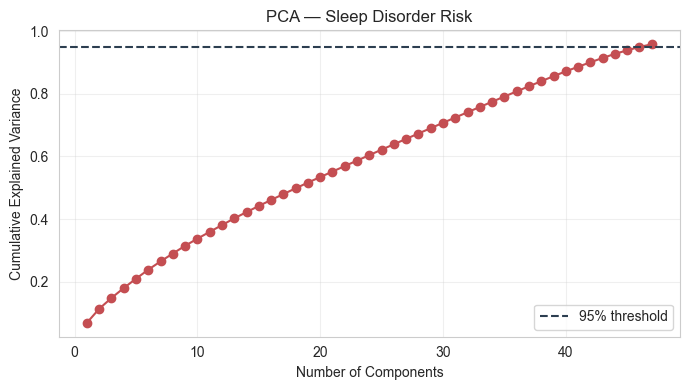

In [38]:
cum_var2 = np.cumsum(pca2.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_var2) + 1), cum_var2, marker='o', color='#C44E52')
ax.axhline(0.95, color='#2c3e50', linestyle='--', label='95% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Sleep Disorder Risk')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Modeling

In [39]:
sw2 = compute_sample_weight(class_weight='balanced', y=y2_train)

models_2 = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=8, min_samples_leaf=20, random_state=42),
}

preds_2 = {}

for name, m in models_2.items():
    if name == 'HistGradientBoosting':
        m.fit(X2_train, y2_train, sample_weight=sw2)
    else:
        m.fit(X2_train, y2_train)
    preds_2[name] = m.predict(X2_test)
    print(f"{name:22s} Accuracy: {accuracy_score(y2_test, preds_2[name]):.4f}")

Random Forest          Accuracy: 0.8710
HistGradientBoosting   Accuracy: 0.9496


## Evaluation

### Accuracy

In [40]:
print(f"Random Forest: {accuracy_score(y2_test, preds_2['Random Forest']):.4f}")
print(f"HistGradientBoosting: {accuracy_score(y2_test, preds_2['HistGradientBoosting']):.4f}")

Random Forest: 0.8710
HistGradientBoosting: 0.9496


### Precision

In [41]:
print(f"Random Forest: {precision_score(y2_test, preds_2['Random Forest'], average='weighted'):.4f}")
print(f"HistGradientBoosting: {precision_score(y2_test, preds_2['HistGradientBoosting'], average='weighted'):.4f}")

Random Forest: 0.8810
HistGradientBoosting: 0.9556


### Recall

In [42]:
print(f"Random Forest: {recall_score(y2_test, preds_2['Random Forest'], average='weighted'):.4f}")
print(f"HistGradientBoosting: {recall_score(y2_test, preds_2['HistGradientBoosting'], average='weighted'):.4f}")

Random Forest: 0.8710
HistGradientBoosting: 0.9496


### F1

In [43]:
print(f"Random Forest: {f1_score(y2_test, preds_2['Random Forest'], average='weighted'):.4f}")
print(f"HistGradientBoosting: {f1_score(y2_test, preds_2['HistGradientBoosting'], average='weighted'):.4f}")

Random Forest: 0.8747
HistGradientBoosting: 0.9516


## Random Forest vs. HistGradientBoosting

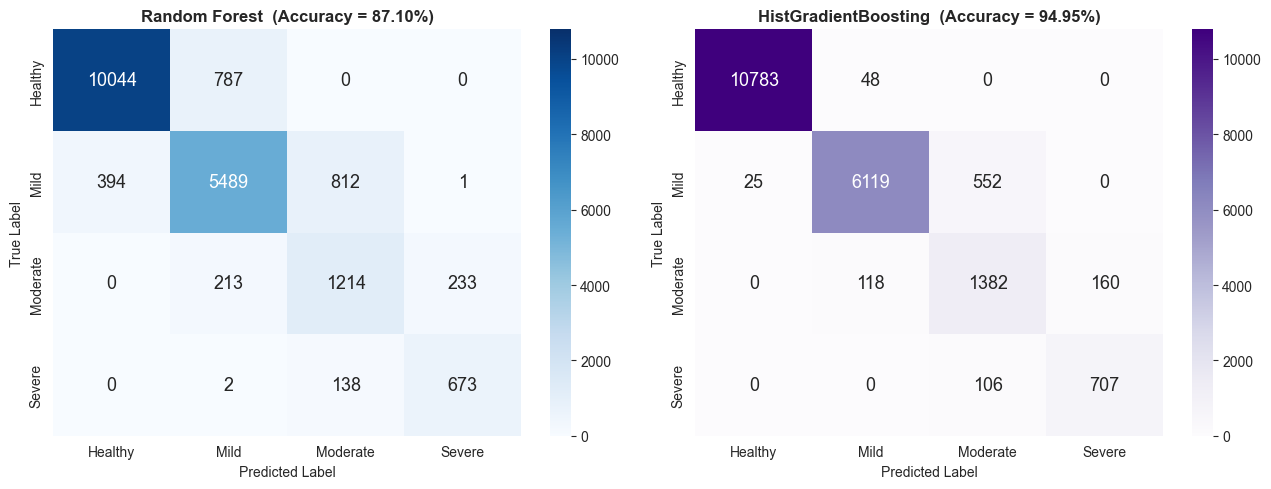

In [44]:
class_names_2 = sorted(y2.unique().astype(str))
two = ['Random Forest', 'HistGradientBoosting']

cms2 = [confusion_matrix(y2_test, preds_2[n]) for n in two]
vmax2 = max(cm.max() for cm in cms2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, name, cmap in zip(axes, cms2, two, ['Blues', 'Purples']):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
                xticklabels=class_names_2, yticklabels=class_names_2,
                ax=ax, vmin=0, vmax=vmax2, annot_kws={'size': 13})
    acc = np.trace(cm) / cm.sum()
    ax.set_title(f'{name}  (Accuracy = {acc:.2%})', fontsize=12, weight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Target 3. Predicting Felt Rested

### Train and Test Split

In [45]:
target_3 = 'felt_rested'

X3 = df.drop(columns=leak_cols + chart_cols)
y3 = df[target_3]

obj_cols_3 = X3.select_dtypes(include='object').columns.tolist()
X3 = pd.get_dummies(X3, columns=obj_cols_3, drop_first=True)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

C:\Users\abdns\AppData\Local\Temp\ipykernel_21032\1687890038.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols_3 = X3.select_dtypes(include='object').columns.tolist()


### Feature Scaling

In [46]:
sc3 = StandardScaler()

X3_train_s = sc3.fit_transform(X3_train)
X3_test_s  = sc3.transform(X3_test)

### PCA

In [47]:
pca3 = PCA(n_components=0.95, random_state=42)

X3_train_pca = pca3.fit_transform(X3_train_s)
X3_test_pca  = pca3.transform(X3_test_s)

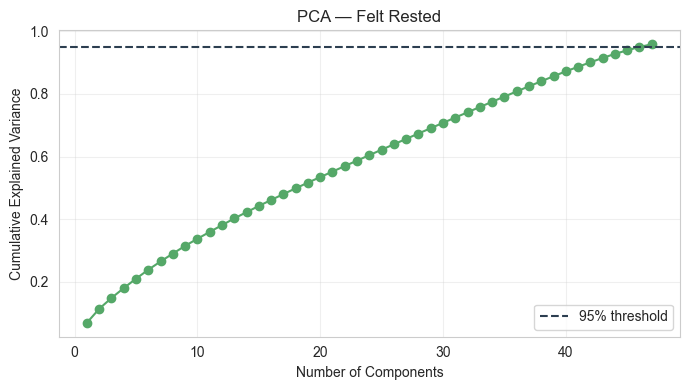

In [48]:
cum_var3 = np.cumsum(pca3.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_var3) + 1), cum_var3, marker='o', color='#55A868')
ax.axhline(0.95, color='#2c3e50', linestyle='--', label='95% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Felt Rested')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Modeling

In [49]:
sw3 = compute_sample_weight(class_weight='balanced', y=y3_train)

models_3 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=6, min_samples_leaf=20, random_state=42),
}

preds_3, probas_3 = {}, {}

for name, m in models_3.items():
    if name == 'HistGradientBoosting':
        m.fit(X3_train, y3_train, sample_weight=sw3)
        preds_3[name]  = m.predict(X3_test)
        probas_3[name] = m.predict_proba(X3_test)[:, 1]
    else:
        m.fit(X3_train_s, y3_train)
        preds_3[name]  = m.predict(X3_test_s)
        probas_3[name] = m.predict_proba(X3_test_s)[:, 1]
    print(f"{name:22s} Accuracy: {accuracy_score(y3_test, preds_3[name]):.4f}")

Logistic Regression    Accuracy: 0.7300
HistGradientBoosting   Accuracy: 0.7244


## Evaluation

### Accuracy

In [50]:
print(f"Logistic Regression: {accuracy_score(y3_test, preds_3['Logistic Regression']):.4f}")
print(f"HistGradientBoosting: {accuracy_score(y3_test, preds_3['HistGradientBoosting']):.4f}")

Logistic Regression: 0.7300
HistGradientBoosting: 0.7244


### Precision

In [51]:
print(f"Logistic Regression: {precision_score(y3_test, preds_3['Logistic Regression']):.4f}")
print(f"HistGradientBoosting: {precision_score(y3_test, preds_3['HistGradientBoosting']):.4f}")

Logistic Regression: 0.6315
HistGradientBoosting: 0.6112


### Recall

In [52]:
print(f"Logistic Regression: {recall_score(y3_test, preds_3['Logistic Regression']):.4f}")
print(f"HistGradientBoosting: {recall_score(y3_test, preds_3['HistGradientBoosting']):.4f}")

Logistic Regression: 0.7396
HistGradientBoosting: 0.8067


### F1

In [53]:
print(f"Logistic Regression: {f1_score(y3_test, preds_3['Logistic Regression']):.4f}")
print(f"HistGradientBoosting: {f1_score(y3_test, preds_3['HistGradientBoosting']):.4f}")

Logistic Regression: 0.6813
HistGradientBoosting: 0.6955


### ROC-AUC

In [54]:
print(f"Logistic Regression: {roc_auc_score(y3_test, probas_3['Logistic Regression']):.4f}")
print(f"HistGradientBoosting: {roc_auc_score(y3_test, probas_3['HistGradientBoosting']):.4f}")

Logistic Regression: 0.8092
HistGradientBoosting: 0.8220


## Logistic Regression vs. HistGradientBoosting

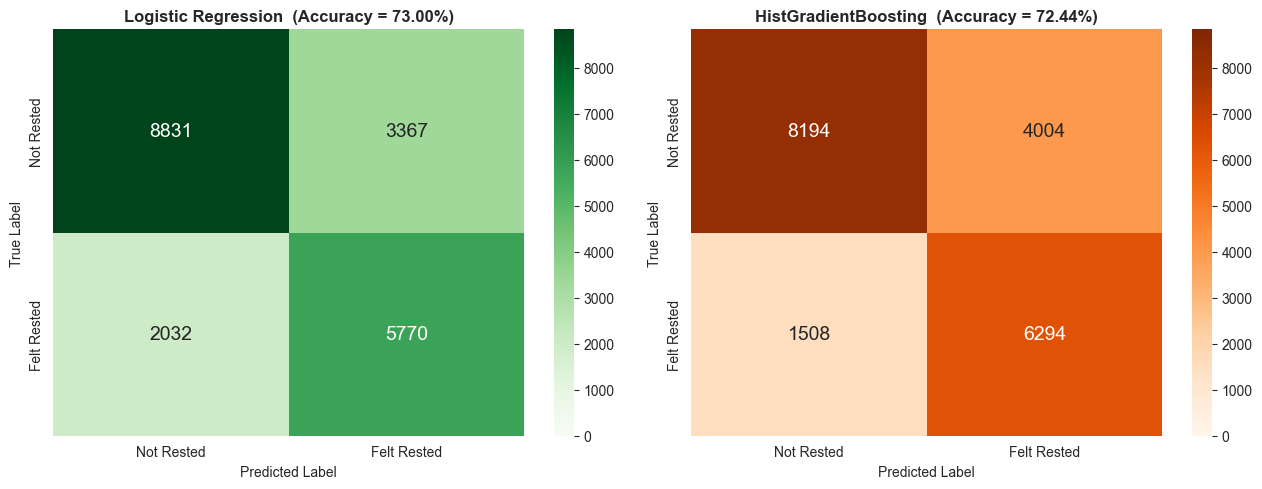

In [55]:
class_names_3 = ['Not Rested', 'Felt Rested']
two3 = ['Logistic Regression', 'HistGradientBoosting']

cms3 = [confusion_matrix(y3_test, preds_3[n]) for n in two3]
vmax3 = max(cm.max() for cm in cms3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, name, cmap in zip(axes, cms3, two3, ['Greens', 'Oranges']):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
                xticklabels=class_names_3, yticklabels=class_names_3,
                ax=ax, vmin=0, vmax=vmax3, annot_kws={'size': 14})
    acc = np.trace(cm) / cm.sum()
    ax.set_title(f'{name}  (Accuracy = {acc:.2%})', fontsize=12, weight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Target 4. Personalized Bedtime Recommendation

### Train and Test Split

In [56]:
control_cols = ['age', 'gender', 'bmi', 'occupation', 'chronotype', 'stress_score',
'sleep_duration_hrs', 'work_hours_that_day', 'exercise_day', 'steps_that_day',
'shift_work', 'caffeine_mg_before_bed', 'alcohol_units_before_bed',
'screen_time_before_bed_hrs', 'room_temperature_celsius', 'nap_duration_mins',
'took_nap', 'stimulant_load', 'sleep_debt', 'work_stress_load',
'mental_health_condition']

control_cols = [c for c in control_cols if c in df.columns]

X4 = df[control_cols]
y4 = df['sleep_quality_score']

obj_cols_4 = X4.select_dtypes(include='object').columns.tolist()
X4 = pd.get_dummies(X4, columns=obj_cols_4, drop_first=True)

X4_train, X4_test, y4_train, y4_test = train_test_split( X4, y4, test_size=0.2, random_state=42)
                    

C:\Users\abdns\AppData\Local\Temp\ipykernel_21032\2833026695.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols_4 = X4.select_dtypes(include='object').columns.tolist()


### Feature Scaling

In [57]:
sc4 = StandardScaler()

X4_train_s = sc4.fit_transform(X4_train)
X4_test_s  = sc4.transform(X4_test)

## Modeling

### Model 1. Ridge

In [58]:
ridge4 = Ridge(alpha=1.0)
ridge4.fit(X4_train_s, y4_train)

y4_predict_ridge = ridge4.predict(X4_test_s)

print(f"MAE: {mean_absolute_error(y4_test, y4_predict_ridge):.4f}")
print(f"R²:  {r2_score(y4_test, y4_predict_ridge):.4f}")

MAE: 0.6707
R²:  0.6941


### Model 2. Random Forest

In [59]:
rf4 = RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf4.fit(X4_train, y4_train)

y4_predict_rf = rf4.predict(X4_test)

print(f"MAE: {mean_absolute_error(y4_test, y4_predict_rf):.4f}")
print(f"R²:  {r2_score(y4_test, y4_predict_rf):.4f}")

MAE: 0.5962
R²:  0.7588


## Evaluation

### MAE

In [60]:
print(f"Ridge: {mean_absolute_error(y4_test, y4_predict_ridge):.4f}")
print(f"Random Forest: {mean_absolute_error(y4_test, y4_predict_rf):.4f}")

Ridge: 0.6707
Random Forest: 0.5962


### RMSE

In [61]:
print(f"Ridge: {np.sqrt(mean_squared_error(y4_test, y4_predict_ridge)):.4f}")
print(f"Random Forest: {np.sqrt(mean_squared_error(y4_test, y4_predict_rf)):.4f}")

Ridge: 0.8379
Random Forest: 0.7441


### R²

In [62]:
print(f"Ridge: {r2_score(y4_test, y4_predict_ridge):.4f}")
print(f"Random Forest: {r2_score(y4_test, y4_predict_rf):.4f}")

Ridge: 0.6941
Random Forest: 0.7588


## Ridge vs. Random Forest

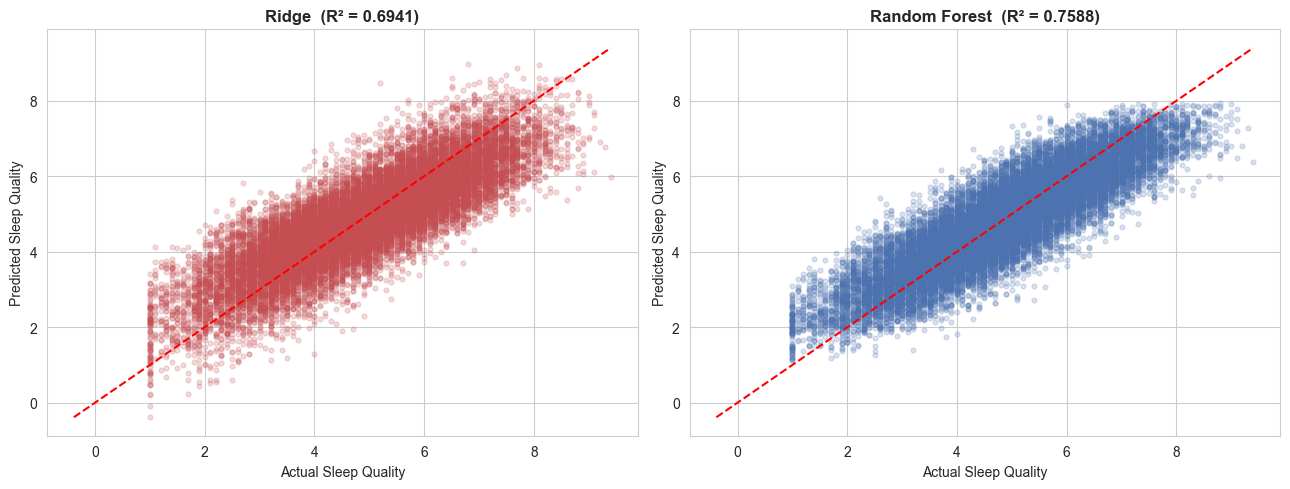

In [63]:
lo = min(y4_test.min(), y4_predict_ridge.min(), y4_predict_rf.min())
hi = max(y4_test.max(), y4_predict_ridge.max(), y4_predict_rf.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title, color in zip(
        axes,
        [y4_predict_ridge, y4_predict_rf],
        ['Ridge', 'Random Forest'],
        ['#C44E52', '#4C72B0']):

    ax.scatter(y4_test, pred, alpha=0.2, s=12, color=color)
    ax.plot([lo, hi], [lo, hi], color='red', linestyle='--')
    ax.set_title(f'{title}  (R² = {r2_score(y4_test, pred):.4f})', fontsize=12, weight='bold')
    ax.set_xlabel('Actual Sleep Quality')
    ax.set_ylabel('Predicted Sleep Quality')

plt.tight_layout()
plt.show()

### Building the Recommendation

In [64]:
#defaults used when a user does not provide a feature
defaults = X4.median().to_dict()

def recommend_bedtime(user_input, wake_up_time="07:00"):
    profile = defaults.copy()
    for k, v in user_input.items():
        if k in profile:
            profile[k] = v

    #try many sleep durations and let the model pick the best one
    durations = np.arange(5.0, 10.25, 0.25)
    rows = []
    for d in durations:
        c = profile.copy()
        c['sleep_duration_hrs'] = d
        rows.append(c)

    cand = pd.DataFrame(rows)[X4.columns]
    quality = rf4.predict(cand)

    best_i = int(np.argmax(quality))
    best_hours = float(durations[best_i])
    best_quality = float(quality[best_i])

    #convert the chosen duration into a bedtime
    wh, wm = map(int, wake_up_time.split(":"))
    bed = (wh * 60 + wm) - int(round(best_hours * 60))
    if bed < 0:
        bed += 1440
    bedtime = f"{(bed // 60) % 24:02d}:{bed % 60:02d}"

    return {'bedtime': bedtime, 'hours': round(best_hours, 2),
            'quality': round(best_quality, 2),
            'search': pd.DataFrame({'hours': durations, 'quality': quality})}

In [65]:
#stressed office worker, heavy caffeine, no exercise
user_1 = {'age':34, 'bmi':27.5, 'stress_score':8, 'work_hours_that_day':10,
          'exercise_day':0, 'steps_that_day':4000, 'shift_work':0,
          'caffeine_mg_before_bed':120, 'screen_time_before_bed_hrs':1.5,
          'room_temperature_celsius':26}

r1 = recommend_bedtime(user_1, wake_up_time="07:00")

print(f"Recommended bedtime: {r1['bedtime']}")
print(f"Sleep duration:      {r1['hours']} hours")
print(f"Predicted quality:   {r1['quality']} / 10")

Recommended bedtime: 00:00
Sleep duration:      7.0 hours
Predicted quality:   5.28 / 10


In [66]:
#relaxed person, healthy habits, no caffeine
user_2 = {'age':27, 'bmi':22.0, 'stress_score':2, 'work_hours_that_day':7,
          'exercise_day':1, 'steps_that_day':11000, 'shift_work':0,
          'caffeine_mg_before_bed':0, 'screen_time_before_bed_hrs':0.25,
          'room_temperature_celsius':20}

r2 = recommend_bedtime(user_2, wake_up_time="06:30")

print(f"Recommended bedtime: {r2['bedtime']}")
print(f"Sleep duration:      {r2['hours']} hours")
print(f"Predicted quality:   {r2['quality']} / 10")

Recommended bedtime: 20:30
Sleep duration:      10.0 hours
Predicted quality:   7.39 / 10


In [67]:
compare = pd.DataFrame({
    'User': ['Stressed Worker', 'Healthy Person'],
    'Wake Up': ['07:00', '06:30'],
    'Bedtime': [r1['bedtime'], r2['bedtime']],
    'Hours': [r1['hours'], r2['hours']],
    'Predicted Quality': [r1['quality'], r2['quality']]
})

compare

,User,Wake Up,Bedtime,Hours,Predicted Quality
0,Stressed Worker,07:00,00:00,7.0,5.28
1,Healthy Person,06:30,20:30,10.0,7.39
